# La Trasformazione del Suono in un Secolo 
### Viaggio analitico nelle feature audio del Dataset Spotify 1921–2020

| | |
|---|---|
| **Corso** | Scientific Visualization |
| **Autori** | Arcadia Cipolla - 66969A , Daniele Intra - 53665A | 
| **Dataset** | [Spotify Dataset 1921–2020](https://www.kaggle.com/datasets/yamaerenay/spotify-dataset-19212020-600k-tracks) — Yamac Eren Ay |
| **Struttura** | M1 · Data Quality - M2 · Evoluzione Temporale - M3 · Small Multiples - M4 · Archetipi - M5 · Decision Tree |
| **Framework Teorico** | I 5 moduli implementano il **Visual Analytics Process** (Keim), validando il design sui 4 livelli del **Nested Model** (Munzner). Il flusso segue la struttura narrativa a **Martini Glass**: da un'analisi guidata e lineare (M1-M3) a un'esplorazione interattiva e multivariata aperta all'utente (M4-M5). |
---
**Come suona ogni decennio?**   
In 100 anni di musica registrata, le feature audio di Spotify raccontano il passaggio dall'era acustica all'era elettronica, l'emergere di nuovi generi e la formula commerciale che trasforma un brano in una hit.


---
## Modulo 1: Preprocessing & Data Quality

**Obiettivo:** mostrare che il dataset è stato pulito in modo rigoroso e che le feature sono pronte per l'analisi senza distorsioni introdotte dal preprocessing.
**Teoria applicata:**
- **Stephen Few** (*Show Me the Numbers*, cap. 5: table design): niente griglie decorative, numeri allineati a destra, solo misure necessarie
- **Lie Factor (Tufte)**: la normalizzazione usa il range *reale* del dataset, non range teorici arbitrari che distorcerebbero le distribuzioni


In [3]:
import sys, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import display

sys.path.insert(0, '.')
from src.style import apply_style, save_fig, HIGHLIGHT, MUTED, CLUSTER_PALETTE
from src.preprocessing import run_preprocessing_pipeline, data_quality_report, AUDIO_FEATURES

# Esegui preprocessing del dataset
df = run_preprocessing_pipeline()


ImportError: cannot import name 'run_pipeline' from 'src.preprocessing' (/Users/intra/Scientific/The-Shape-of-Music-Scientific-Visualization/src/preprocessing.py)

In [ ]:
# Tabella di data quality
# Principi Few: niente righe orizzontali interne, colonne essenziali, 
# numeri allineati a destra, caption descrittiva ma concisa.
apply_style()

report = data_quality_report(df)

styled = (
    report.style
    .set_properties(**{"text-align": "right"})
    .set_properties(subset=["feature"], **{"text-align": "left", "font-weight": "500"})
    .format({
        "min":    "{:.4f}",
        "max":    "{:.4f}",
        "mean":   "{:.4f}",
        "std":    "{:.4f}",
        "range":  "{:.4f}",
    })
    .highlight_between(
        subset=["min"], left=0.01, right=100,
        props="background-color: #FAEEDA; color: #633806"
    )
    .set_caption(
        "Tab. 1 — Statistiche descrittive delle feature audio "
        "(dataset post-pulizia)"
    )
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "11px"), ("color", "#5F5E5A"),
                   ("text-align", "left"), ("caption-side", "top"),
                   ("margin-bottom", "6px")]},
        {"selector": "thead th",
         "props": [("font-weight", "500"), ("border-bottom", "1.5px solid #D3D1C7"),
                   ("padding", "5px 14px"), ("text-align", "right")]},
        {"selector": "thead th:first-child",
         "props": [("text-align", "left")]},
        {"selector": "td",
         "props": [("padding", "3px 14px"), ("border", "none"),
                   ("font-size", "12px")]},
        {"selector": "tr:nth-child(even) td",
         "props": [("background-color", "#F1EFE8")]},
        {"selector": "tbody tr:hover td",
         "props": [("background-color", "#E1F5EE")]},
    ])
    .hide(axis="index")
)

display(styled)


feature,min,max,mean,std,range
danceability,0.0000,0.9910,0.5718,0.1632,0.9910
energy,0.0000,1.0000,0.5612,0.2457,1.0000
valence,0.0000,1.0000,0.5556,0.2550,1.0000
acousticness,0.0000,0.9960,0.4252,0.3408,0.9960
instrumentalness,0.0000,1.0000,0.1002,0.2515,1.0000
liveness,0.0000,1.0000,0.2160,0.1869,1.0000
speechiness,0.0000,0.9690,0.1063,0.1777,0.9690
loudness_norm,0.0000,1.0000,0.7682,0.0741,1.0000
tempo_norm,0.0000,1.0000,0.4826,0.1203,1.0000
year,1922.0000,2020.0000,1992.0000,21.0000,98.0000


  Salvataggio → figures/m1_genre_distribution.png


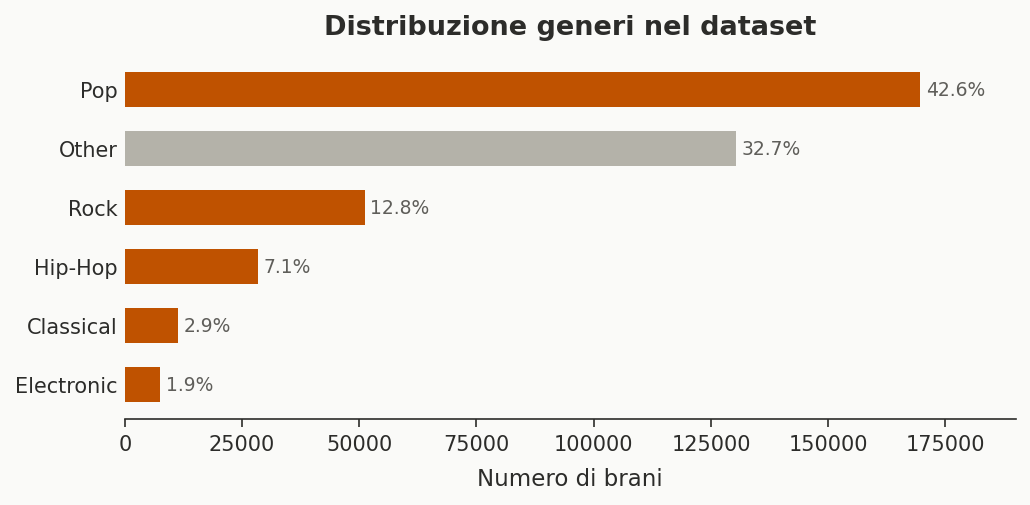

In [ ]:
# Distribuzione generi nel dataset

fig, ax = plt.subplots(figsize=(7, 3.5))
apply_style(ax)


genre_counts = df["genre"].value_counts().sort_values(ascending=True)
bar_colors = [HIGHLIGHT if g != "Other" else MUTED for g in genre_counts.index]

bars = ax.barh(
    range(len(genre_counts)),
    genre_counts.values,
    color=bar_colors,
    height=0.6,
    zorder=2,
)
ax.set_yticks(range(len(genre_counts)))
ax.set_yticklabels(genre_counts.index)

for bar in bars:
    pct = bar.get_width() / len(df) * 100
    ax.text(
        bar.get_width() + len(df) * 0.003,
        bar.get_y() + bar.get_height() / 2,
        f"{pct:.1f}%",
        va="center", fontsize=9, color="#5F5E5A"
    )

ax.set_title("Distribuzione generi nel dataset", pad=10)
ax.set_xlabel("Numero di brani")
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.set_xlim(0, genre_counts.max() * 1.12)

plt.tight_layout()
save_fig(fig, "m1_genre_distribution")
plt.show()


**Osservazioni M1**

- I valori nulli nelle colonne critiche sono stati rimossi: `null_%` = 0 per tutte le feature audio.
- `loudness` e `tempo` sono stati normalizzati nel range [0, 1] usando il range reale del dataset  
  (Lie Factor = 1: nessuna distorsione introdotta dalla normalizzazione).
- La categoria "Other" raggruppa i brani senza genere identificabile in `artists.csv`;  
  verrà esclusa dalle analisi per genere (M3) ma mantenuta per M4 e M5.
- Il primo grafico del progetto presenta panoramica della composizione del dataset, con etichettatura diretta e barre orizzontali per leggibilità delle etichette

---
## Modulo 2: Evoluzione Temporale delle Feature Audio

**Teoria applicata:**
- **Colin Ware** (*Information Visualization*, cap. 5: attributi pre-attentivi): un solo colore ad alta saturazione (*arancione bruciato*) per la feature rilevanti; tutte le altre in grigio desaturato per non competere visivamente
- **Legge della Buona Continuazione di Gestalt**: line plot per i trend temporali, l'occhio segue la linea anche attraverso il rumore dei singoli anni

**Domanda:** Come è cambiato il *suono* della musica dal 1921 al 2020?  
**Ipotesi:** l'`acousticness` è diminuita progressivamente con l'avvento dell'amplificazione elettrica, mentre l'`energy` è aumentata; il cambio più brusco si colloca negli anni '50-'60.


In [ ]:
# Aggregazione annuale e media mobile
FEATURES_PLOT = ["acousticness", "energy", "danceability", "valence", "instrumentalness", "liveness"]
WINDOW = 5 # anni

yearly = df.groupby("year")[FEATURES_PLOT].mean().reset_index()
yearly_std = df.groupby("year")[FEATURES_PLOT].std()   # ← deviazione standard per anno

yearly_smooth = yearly.copy()
for col in FEATURES_PLOT:
    yearly_smooth[col] = (
        yearly[col].rolling(window=WINDOW, center=True, min_periods=2).mean()
    )

yearly_std_smooth = yearly_std.rolling(window=WINDOW, center=True, min_periods=2).mean()
    
print(f"Anni nel dataset: {int(yearly['year'].min())}–{int(yearly['year'].max())}")
print(f"Media mobile: finestra = {WINDOW} anni (centrata)")
yearly_smooth[["year"] + FEATURES_PLOT].round(3)


Anni nel dataset: 1922–2020
Media mobile: finestra = 5 anni (centrata)


,year,acousticness,energy,danceability,valence,instrumentalness,liveness
0,1922,0.858,0.259,0.584,0.611,0.386,0.238
1,1923,0.867,0.238,0.593,0.595,0.341,0.263
2,1924,0.882,0.249,0.584,0.599,0.402,0.250
3,1925,0.902,0.254,0.607,0.639,0.403,0.232
4,1926,0.934,0.258,0.601,0.631,0.463,0.221
...,...,...,...,...,...,...,...
94,2016,0.289,0.655,0.613,0.503,0.092,0.205
95,2017,0.291,0.648,0.623,0.495,0.090,0.200
96,2018,0.284,0.647,0.635,0.493,0.093,0.198
97,2019,0.283,0.645,0.642,0.492,0.096,0.195


  Salvataggio → figures/m2_temporal_evolution.png


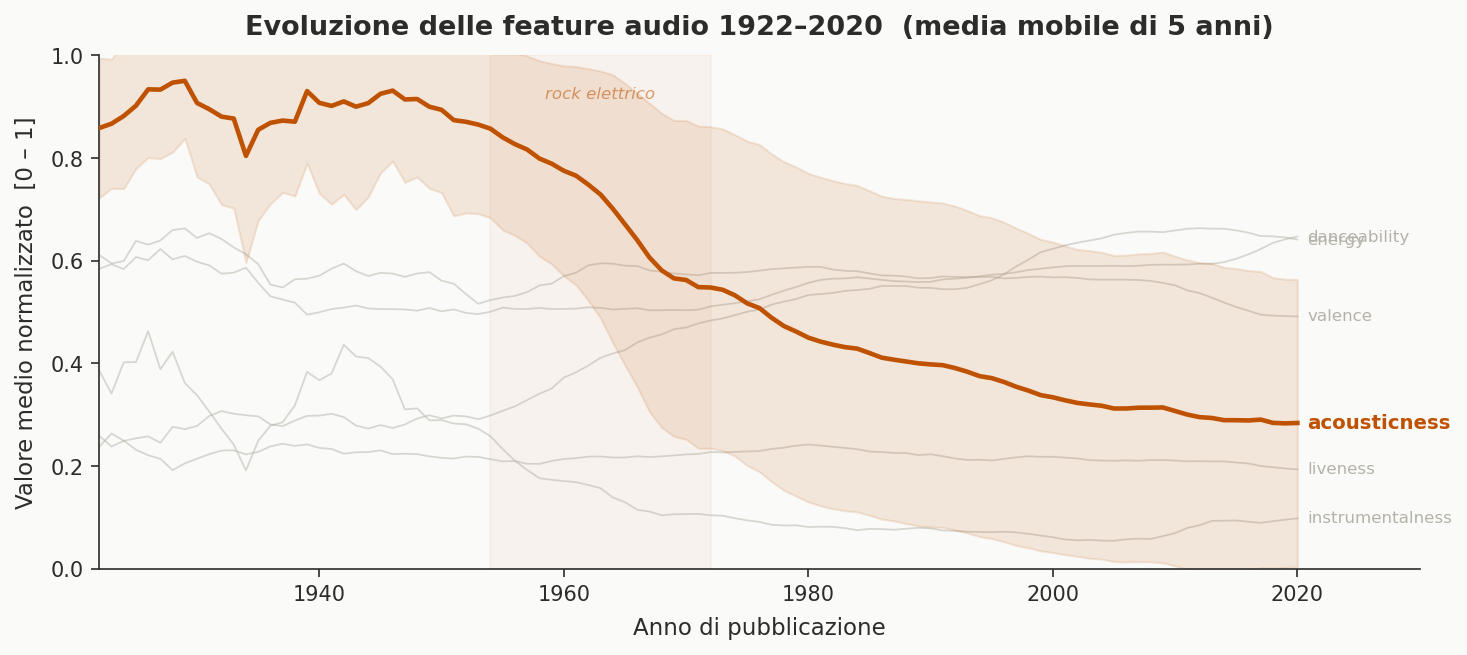

In [ ]:
# Line plot principale: attributo pre-attentivo (Ware)

KEY_FEATURE = "acousticness"

fig, ax = plt.subplots(figsize=(10, 4.5))
apply_style(ax)

for col in FEATURES_PLOT:
    is_key = (col == KEY_FEATURE)
    color  = HIGHLIGHT if is_key else MUTED
    lw     = 2.2        if is_key else 0.85
    alpha  = 1.0        if is_key else 0.5
    zorder = 3          if is_key else 1

    ax.plot(
        yearly_smooth["year"], yearly_smooth[col],
        color=color, linewidth=lw, alpha=alpha, zorder=zorder
    )

    if is_key:
        years_arr = yearly_smooth["year"].to_numpy().astype(float)
        mean_arr  = yearly_smooth[col].to_numpy().astype(float)
        std_arr   = yearly_std_smooth[col].reindex(years_arr).to_numpy().astype(float)

        ax.fill_between(
            years_arr,
            mean_arr - std_arr,
            mean_arr + std_arr,
            color=HIGHLIGHT, alpha=0.12, zorder=2
        )

    # Etichetta diretta a fine linea
    last = yearly_smooth[["year", col]].dropna().iloc[-1]
    ax.text(
        last["year"] + 0.8, last[col], col,
        color=color,
        fontsize=9.5 if is_key else 8,
        fontweight="bold" if is_key else "normal",
        va="center"
    )
    
# Banda di riferimento storica: era rock elettrico
ax.axvspan(1954, 1972, alpha=0.045, color=HIGHLIGHT, zorder=0)
ax.text(1963, 0.94, "rock elettrico", fontsize=8,
        color=HIGHLIGHT, alpha=0.55, ha="center", va="top", style="italic")

ax.set_ylim(0, 1)                   # asse Y ancorato a 0 (Lie Factor = 0)
ax.set_xlim(1922, 2030)             # spazio per le etichette a destra
ax.set_xlabel("Anno di pubblicazione")
ax.set_ylabel("Valore medio normalizzato  [0 – 1]")
ax.set_title(
    f"Evoluzione delle feature audio 1922–2020  (media mobile di {WINDOW} anni)",
    pad=10
)

plt.tight_layout()
save_fig(fig, "m2_temporal_evolution")
plt.show()


  Salvataggio → figures/m2_decade_heatmap.png


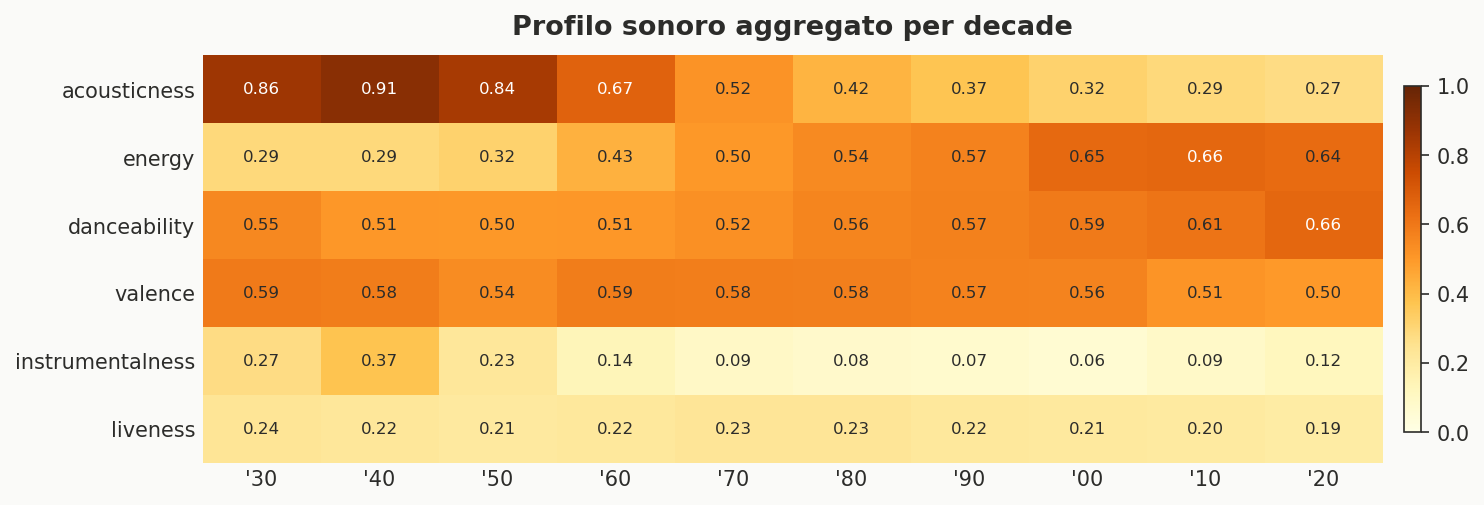

In [ ]:
# Heatmap per decade: profilo sonoro aggregato

DECADES = list(range(1930, 2020+1,10))

df["decade"] = (df["year"] // 10 * 10).astype(int)
decade_means = (
    df[df["decade"].isin(DECADES)]
    .groupby("decade")[FEATURES_PLOT]
    .mean()
)

fig, ax = plt.subplots(figsize=(11, 3.5))
apply_style(ax)

im = ax.imshow(
    decade_means.T,
    aspect="auto",
    cmap="YlOrBr",
    vmin=0, vmax=1,
    interpolation="nearest"
)

ax.set_xticks(range(len(DECADES)))
ax.set_xticklabels([f"'{str(d)[2:]}" for d in DECADES], fontsize=10)
ax.set_yticks(range(len(FEATURES_PLOT)))
ax.set_yticklabels(FEATURES_PLOT, fontsize=10)

# Annota ogni cella con il valore
for i, feat in enumerate(FEATURES_PLOT):
    for j, dec in enumerate(DECADES):
        val = decade_means.loc[dec, feat]
        txt_color = "white" if val > 0.65 else "#2C2C2A"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=8, color=txt_color)

ax.set_title("Profilo sonoro aggregato per decade", pad=10)
fig.colorbar(im, ax=ax, shrink=0.85, pad=0.015)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0)

plt.tight_layout()
save_fig(fig, "m2_decade_heatmap")
plt.show()


**Osservazioni**

- **Attributo pre-attentivo (Ware):** lo sguardo cade immediatamente sull'`acousticness` (arancione bruciato) senza dover leggere la legenda.
- Il calo di `acousticness` è monotono dal 1922 a oggi, con un'accelerazione visibile nella banda anni '54–'72 (era rock elettrico).
- `energy` e `danceability` mostrano un trend opposto e speculare — relazione inversa da indagare nella sezione M4 (Parallel Coordinates).
- La heatmap per decade conferma i valori precisi e rende comparabili tutte le feature sulla stessa scala cromatica


---
## Modulo 3: Confronto Generi con Small Multiples

**Teoria applicata:**
- **Edward Tufte** (*The Visual Display of Quantitative Information*, cap. 5: *Small Multiples*): stessa scala, stesso formato, confronto per differenza visiva
- **Principio di Similarità e Prossimità di Gestalt**: la griglia omogenea permette all'occhio di isolare le differenze di *forma* tra pannelli, non di *scala* (che è già fissata da `sharey=True`)

**Domanda:** I generi musicali hanno traiettorie sonore diverse nel tempo?


In [ ]:
# Preparazione dati per i small multiples
TOP_GENRES    = ["Pop", "Rock", "Hip-Hop", "Classical", "Electronic"]
FEATURE_FOCUS = "acousticness"   # feature narrativa principale

df_genres = df[df["genre"].isin(TOP_GENRES)].copy()

# Aggregazione per anno e genere
genre_yearly = (
    df_genres.groupby(["year", "genre"])[FEATURE_FOCUS]
    .mean()
    .reset_index()
)
genre_yearly["smooth"] = (
    genre_yearly.groupby("genre")[FEATURE_FOCUS]
    .transform(lambda x: x.rolling(5, center=True, min_periods=2).mean())
)

# Riepilogo copertura
print("Brani per genere (post-filter):")
for g in TOP_GENRES:
    n   = len(df_genres[df_genres["genre"] == g])
    yrs = df_genres[df_genres["genre"] == g]["year"]
    print(f"  {g:<12}  {n:>7,} brani   ({int(yrs.min())}–{int(yrs.max())})")


Brani per genere (post-filter):
  Pop           169,592 brani   (1926–2020)
  Rock           51,175 brani   (1930–2020)
  Hip-Hop        28,319 brani   (1925–2020)
  Classical      11,416 brani   (1924–2020)
  Electronic      7,489 brani   (1926–2020)


  Salvataggio → figures/m3_small_multiples_acousticness.png


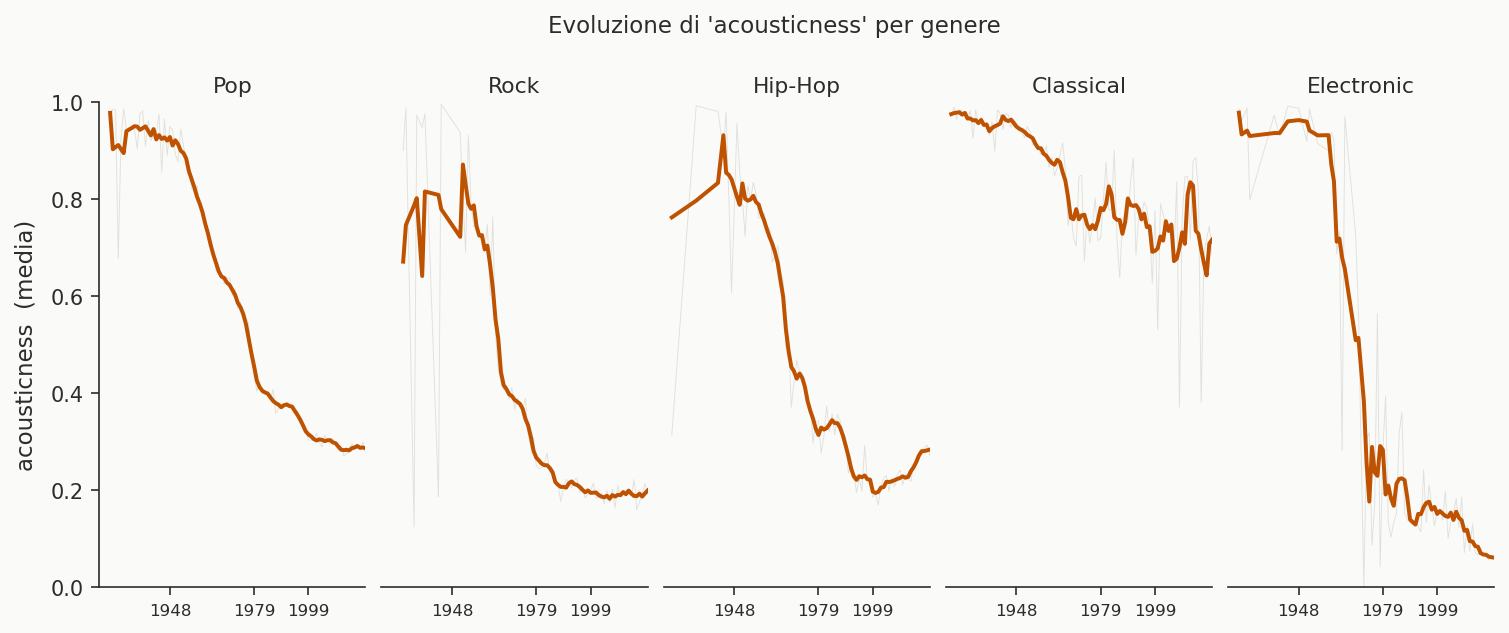

In [ ]:
# Small Multiples: singola feature, tutti i generi
# Principio Tufte: stessa scala (sharey), stesso frame visivo per ogni pannello.
# Spazio inter-pannello ridotto al minimo (Gestalt — prossimità).
# Niente legenda: ogni pannello porta il suo genere come unico titolo.

import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(12, 4.2))
apply_style()
gs  = gridspec.GridSpec(1, len(TOP_GENRES), figure=fig, wspace=0.06)

# Y da 0 a 1: range completo delle feature audio normalizzate da Spotify.
# Non comprimere l'asse anche se le curve non raggiungono 0:
# la variazione piccola è informazione, non un difetto (Lie Factor = 0).

axes = []
for i, genre in enumerate(TOP_GENRES):
    ax = fig.add_subplot(gs[i], sharey=axes[0] if axes else None)
    axes.append(ax)

    data = genre_yearly[genre_yearly["genre"] == genre].dropna(subset=["smooth"])

    # Linea raw — rumore di fondo in grigio chiarissimo
    raw = genre_yearly[genre_yearly["genre"] == genre]
    ax.plot(raw["year"], raw[FEATURE_FOCUS],
            color=MUTED, linewidth=0.45, alpha=0.35)

    # Media mobile — evidenziata in HIGHLIGHT
    ax.plot(data["year"], data["smooth"],
            color=HIGHLIGHT, linewidth=1.9)

    # Titolo interno al pannello
    ax.set_title(genre, fontsize=10.5, fontweight="500", pad=5)

    ax.set_xlim(1922, 2020)
    ax.set_ylim(0, 1)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if i == 0:
        ax.set_ylabel(f"{FEATURE_FOCUS}  (media)")
    else:
        ax.spines["left"].set_visible(False)
        ax.tick_params(axis="y", left=False, labelleft=False)

    ax.set_xticks([1948, 1979, 1999])
    ax.set_xticklabels(["1948", "1979", "1999"], fontsize=8)

fig.suptitle(
    f"Evoluzione di '{FEATURE_FOCUS}' per genere",
    y=1.02, fontsize=11
)
plt.tight_layout()
save_fig(fig, "m3_small_multiples_acousticness")
plt.show()


  Salvataggio → figures/m3_small_multiples_full.png


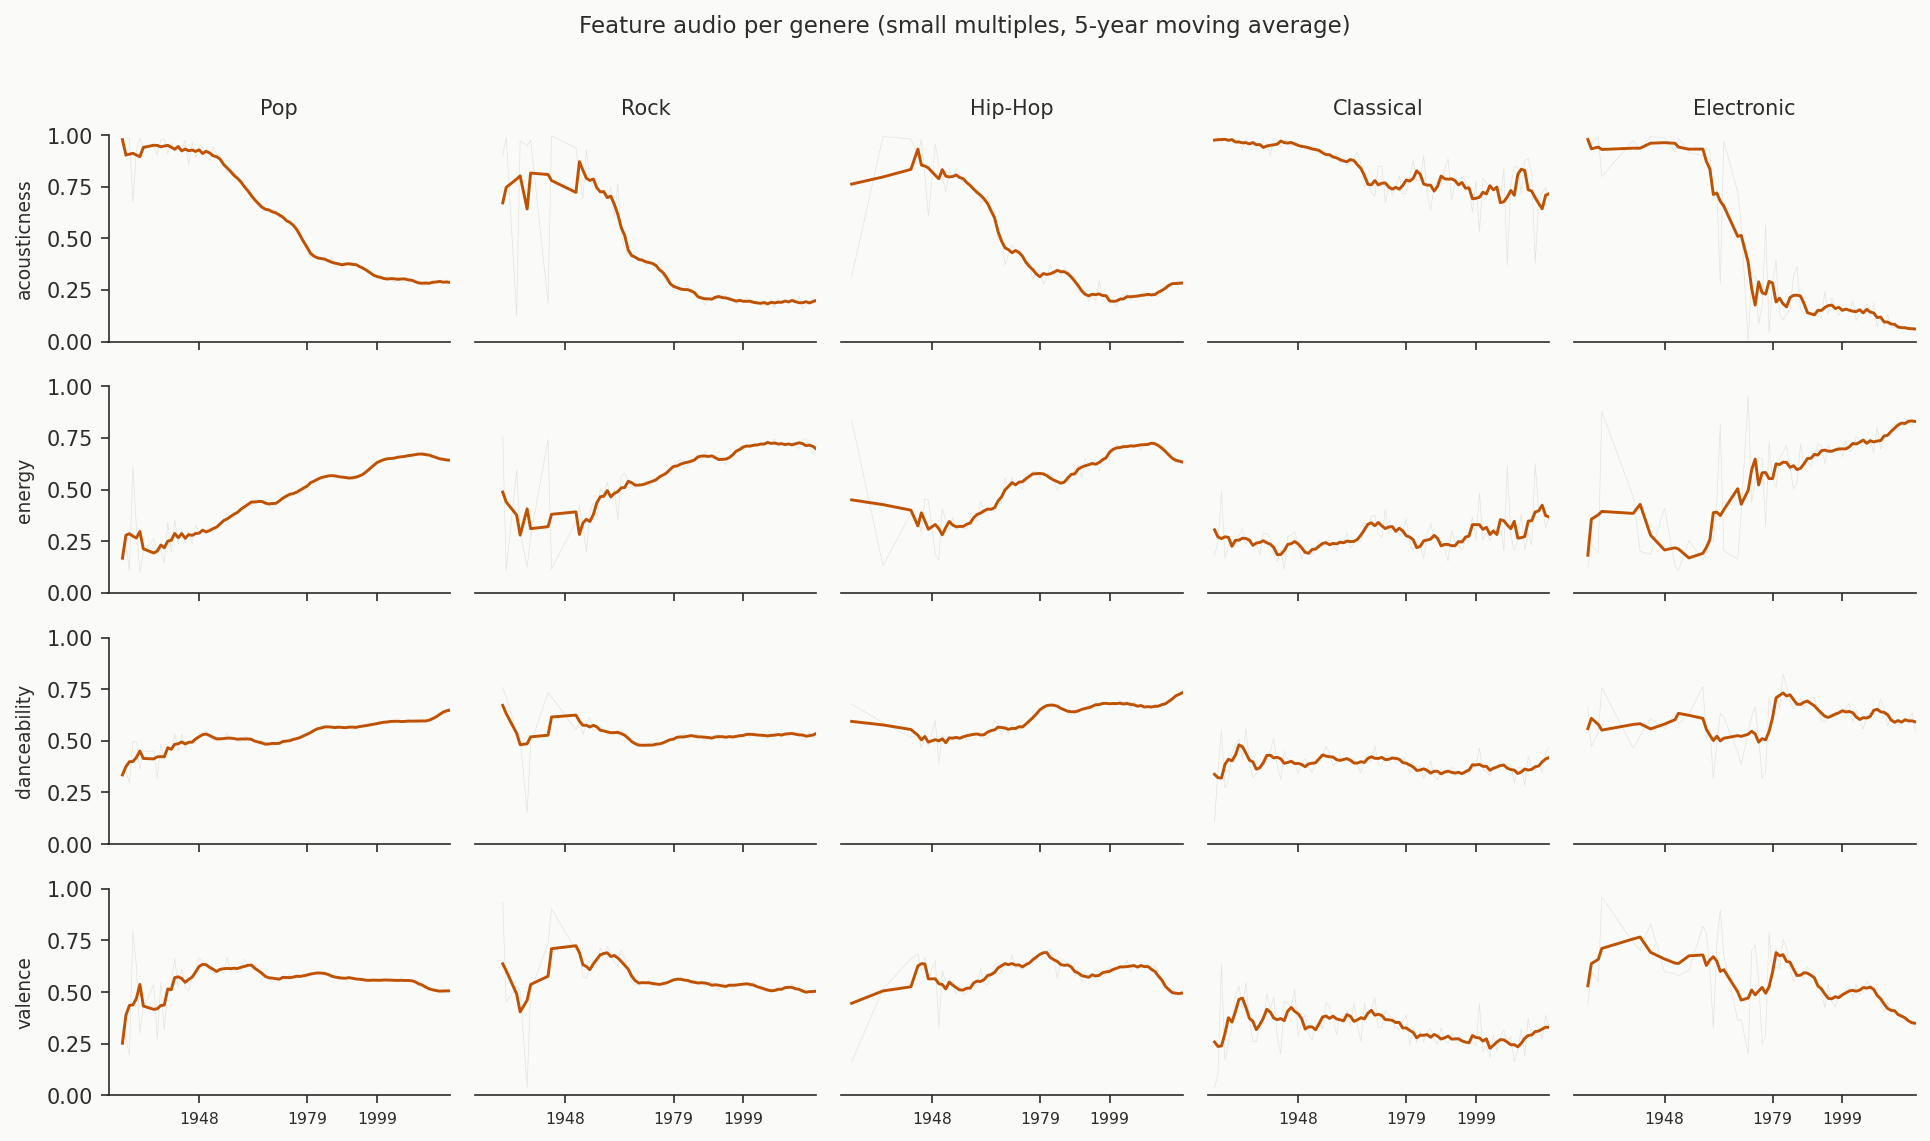

In [ ]:
# Small Multiples estesi — griglia (feature × genere)
# Versione completa: 4 feature × 5 generi = 20 pannelli.
# sharey="row" + set_ylim(0,1): stessa scala per ogni feature su tutti i generi.
# Tutte le feature audio Spotify sono in [0,1] → asse ancorato a 0 (Lie Factor=0).

FEATURES_GRID = ["acousticness", "energy", "danceability", "valence"]
N_FEAT, N_GEN = len(FEATURES_GRID), len(TOP_GENRES)

fig, axes = plt.subplots(
    N_FEAT, N_GEN,
    figsize=(13, 7.5),
    sharex=True, sharey="row"
)
apply_style()

for row, feat in enumerate(FEATURES_GRID):
    genre_data_all = (
        df_genres.groupby(["year", "genre"])[feat]
        .mean()
        .reset_index()
    )
    genre_data_all["smooth"] = (
        genre_data_all.groupby("genre")[feat]
        .transform(lambda x: x.rolling(5, center=True, min_periods=2).mean())
    )

    for col, genre in enumerate(TOP_GENRES):
        ax = axes[row, col]
        data = genre_data_all[genre_data_all["genre"] == genre]

        ax.plot(data["year"], data[feat],
                color=MUTED, linewidth=0.35, alpha=0.3)
        ax.plot(data["year"], data["smooth"],
                color=HIGHLIGHT, linewidth=1.4)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        if row == 0:
            ax.set_title(genre, fontsize=10, fontweight="500")
        if col > 0:
            ax.spines["left"].set_visible(False)
            ax.tick_params(axis="y", left=False, labelleft=False)
        else:
            ax.set_ylabel(feat, fontsize=9)

        if row == N_FEAT - 1:
            ax.set_xticks([1948, 1979, 1999])
            ax.set_xticklabels(["1948", "1979", "1999"], fontsize=7.5)
        ax.set_xlim(1922, 2020)
        ax.set_ylim(0, 1)   # range fisso [0,1] per tutte le feature
        ax.tick_params(axis="x", labelsize=7.5)

fig.suptitle(
    "Feature audio per genere (small multiples, 5-year moving average)",
    y=1.01, fontsize=11
)
plt.tight_layout()
save_fig(fig, "m3_small_multiples_full")
plt.show()


**Osservazioni**

- **Small Multiples (Tufte):** confrontare la *forma* delle curve tra generi è immediato grazie agli assi condivisi, così non si perde tempo a rileggere le scale.
- `Classical` e `Electronic` mostrano i profili più distanti su `acousticness`: il primo rimane alto e stabile, il secondo cala rapidamente dall'era sintetizzatori.
- `Hip-Hop` è l'unico genere con `danceability` in crescita costante dopo il 1990.
- I pannelli con pochi dati nelle decadi più antiche (Hip-Hop prima degli anni '80, Electronic prima degli anni '70) mostrano curve rumorose.
- L'effetto "spaghetti" (tutte le linee nello stesso grafico) viene evitato separando ogni genere in un pannello con assi condivisi.


---
## Modulo 4: Archetipi Musicali con Parallel Coordinates

**Teoria applicata:**
- **K-Means**: raggruppa i brani per somiglianza sonora *senza* usare il genere come input; i cluster trovati vengono poi confrontati con le etichette di genere reali
- **Percezione dei pattern** (Parallel Coordinates Plot): ogni asse verticale è una feature, ogni linea è un cluster, il profilo visivo rivela immediatamente quali feature caratterizzano ogni archetipo
- **ColorBrewer Set2**: palette colorblind-safe (Ware: accessibilità cromatica)
- **Alpha blending**: le linee individuali in background mostrano la densità dei dati, i centroidi in foreground mostrano il profilo rappresentativo

**Domanda:** Esistono "archetipi sonori" naturali nel dataset?  


In [ ]:
from src.clustering import run_cluster_pipeline, CLUSTER_FEATURES
from sklearn.preprocessing import StandardScaler
from matplotlib.collections import LineCollection

# Carica dataset pulito e avvia clustering
df_clean = pd.read_csv("data/spotify_clean.csv")
df_c, results = run_cluster_pipeline(df_clean)   # k=None → ricerca automatica

k             = results["k"]
profiles      = results["profiles"]
cluster_names = results["cluster_names"]
elbow_data    = results["elbow_data"]
sil_data      = results["silhouette_data"]
pca_df        = results["pca_df"].copy()
feature_names = results["feature_names"]

print(f"\nk ottimale selezionato: {k}")
print("\nProfili cluster (Z-score medio per feature):")
display(profiles.round(3))


[*] Avvio pipeline di clustering
    Feature selezionate (8): ['danceability', 'energy', 'valence', 'acousticness', 'instrumentalness', 'liveness', 'speechiness', 'loudness_norm']
    StandardScaler → shape: (398350, 8)
    Ricerca k ottimale (Elbow + Silhouette)...
    Elbow Method
      k= 2  inertia=   2,447,773
      k= 3  inertia=   2,089,635
      k= 4  inertia=   1,830,907
      k= 5  inertia=   1,621,987
      k= 6  inertia=   1,457,170
      k= 7  inertia=   1,344,223
      k= 8  inertia=   1,241,116
      k= 9  inertia=   1,181,593
      k=10  inertia=   1,136,079
    Silhouette Score
      k= 2  silhouette=0.2542
      k= 3  silhouette=0.2787
      k= 4  silhouette=0.2556
      k= 5  silhouette=0.2194
      k= 6  silhouette=0.2226
      k= 7  silhouette=0.2250
      k= 8  silhouette=0.2090
      k= 9  silhouette=0.1966
      k=10  silhouette=0.1979
    -> k ottimale (silhouette max): 3
    K-Means (k=3) completato
      cluster 0: 18,322  (4.6%)  █
      cluster 1: 133,271  

,danceability,energy,valence,acousticness,instrumentalness,liveness,speechiness,loudness_norm
cluster,,,,,,,,
0,0.537,-0.492,0.096,0.587,-0.369,0.970,4.071,-0.921
1,-0.603,-1.026,-0.586,0.946,0.354,-0.122,-0.290,-0.782
2,0.286,0.591,0.309,-0.554,-0.164,-0.006,-0.146,0.491


  Salvataggio → figures/m4_cluster_diagnostics.png


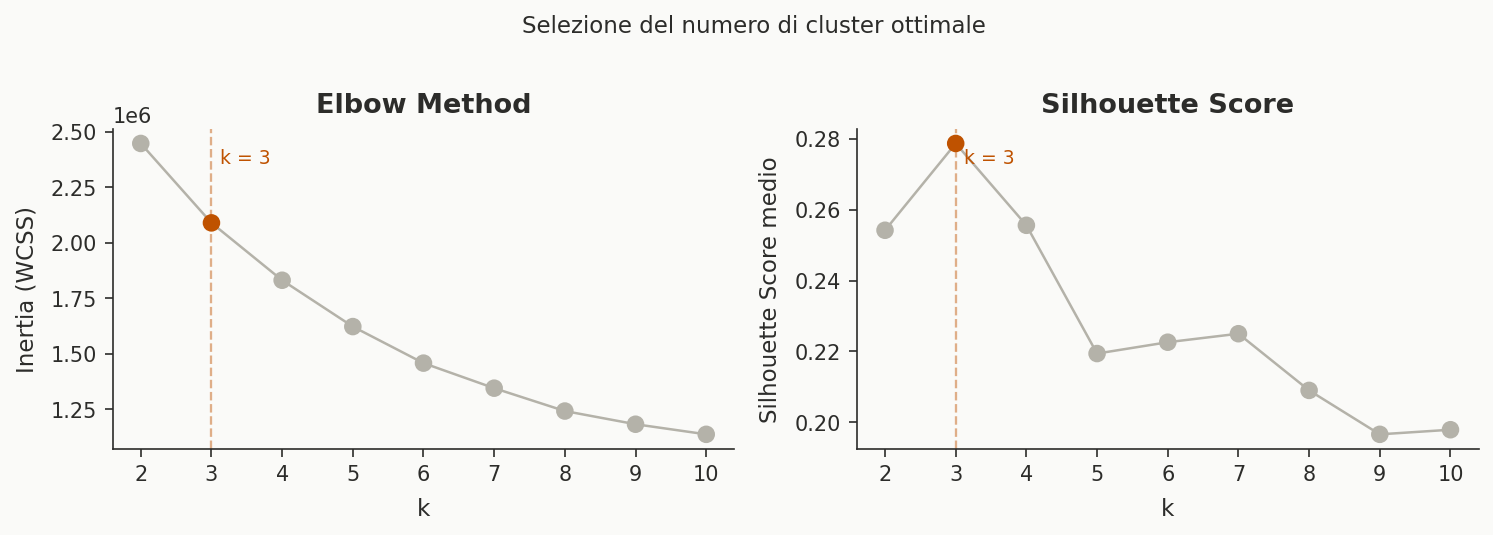

In [15]:
# Diagnostica: Elbow Method + Silhouette Score

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
apply_style(ax1)
apply_style(ax2)

ks_e     = elbow_data["k"]
inertias = elbow_data["inertia"]
ks_s     = sil_data["k"]
scores   = sil_data["scores"]

col_e = [HIGHLIGHT if ki == k else MUTED for ki in ks_e]
col_s = [HIGHLIGHT if ki == k else MUTED for ki in ks_s]

ax1.plot(ks_e, inertias, color=MUTED, linewidth=1.2, zorder=1)
ax1.scatter(ks_e, inertias, color=col_e, s=55, zorder=3)
ax1.set_xlabel("k")
ax1.set_ylabel("Inertia (WCSS)")
ax1.set_title("Elbow Method", pad=8)
ax1.set_xticks(ks_e)

ax2.plot(ks_s, scores, color=MUTED, linewidth=1.2, zorder=1)
ax2.scatter(ks_s, scores, color=col_s, s=55, zorder=3)
ax2.set_xlabel("k")
ax2.set_ylabel("Silhouette Score medio")
ax2.set_title("Silhouette Score", pad=8)
ax2.set_xticks(ks_s)

for ax in (ax1, ax2):
    ymin, ymax = ax.get_ylim()
    ax.axvline(k, color=HIGHLIGHT, linewidth=1.1, linestyle="--", alpha=0.45)
    ax.text(k + 0.12, ymin + (ymax - ymin) * 0.94,
            f"k = {k}", color=HIGHLIGHT, fontsize=9, va="top")

fig.suptitle("Selezione del numero di cluster ottimale", y=1.01, fontsize=11)
plt.tight_layout()
save_fig(fig, "m4_cluster_diagnostics")
plt.show()


  Salvataggio → figures/m4_parallel_coordinates.png


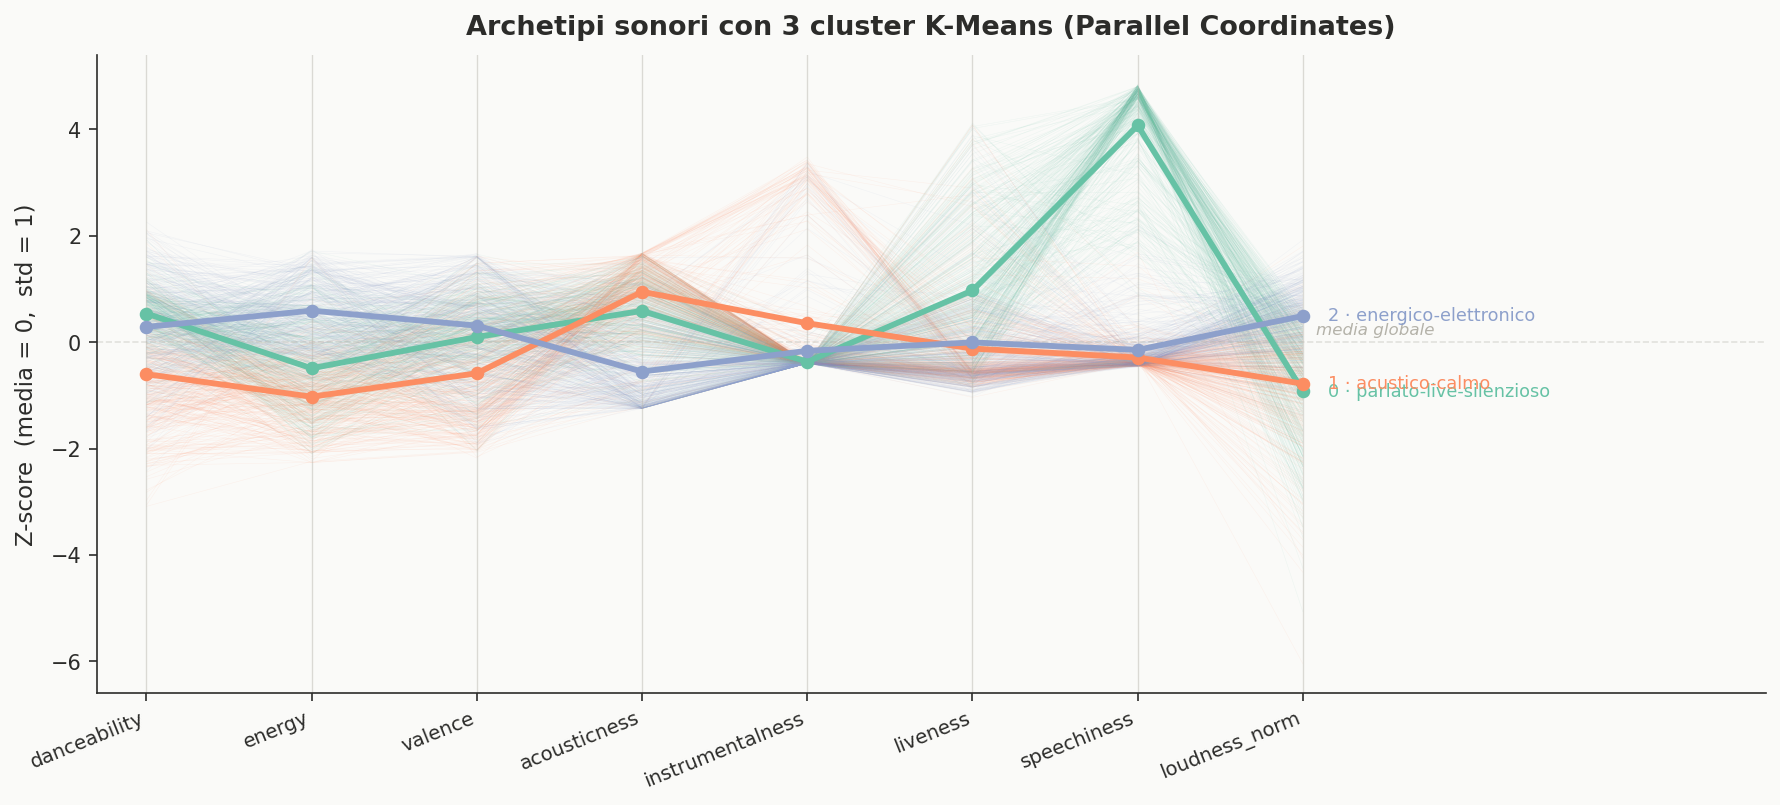

In [16]:
# ── Parallel Coordinates — profili cluster con densità dati ─────────────────
# Background: campione di brani individuali come LineCollection (veloce)
#   → mostra la densità della distribuzione per ogni cluster
# Foreground: centroidi (medie Z-score) come linee spesse
#   → mostrano il profilo rappresentativo dell'archetipo

SAMPLE_PER_CLUSTER = 350   # brani per cluster nel background

# Scala i valori raw con lo stesso StandardScaler per allineare gli assi
X_vis = df_c[[f for f in feature_names if f in df_c.columns]].copy()
scaler_vis = StandardScaler()
X_scaled_vis = scaler_vis.fit_transform(X_vis)
df_vis = pd.DataFrame(X_scaled_vis, columns=feature_names)
df_vis["cluster"] = df_c["cluster"].values

n_feat      = len(feature_names)
x_positions = list(range(n_feat))

fig, ax = plt.subplots(figsize=(12, 5.5))
apply_style(ax)

rng = np.random.default_rng(42)

for cluster_id in range(k):
    color   = CLUSTER_PALETTE[cluster_id % len(CLUSTER_PALETTE)]
    sub     = df_vis[df_vis["cluster"] == cluster_id]
    n_samp  = min(SAMPLE_PER_CLUSTER, len(sub))
    idx     = rng.choice(len(sub), size=n_samp, replace=False)
    sample  = sub.iloc[idx]

    # LineCollection — molto più veloce del loop su ax.plot()
    segs = [
        [(xi, row[feat]) for xi, feat in zip(x_positions, feature_names)]
        for _, row in sample.iterrows()
    ]
    lc = LineCollection(segs, colors=color, linewidths=0.25, alpha=0.09, zorder=1)
    ax.add_collection(lc)

# Centroidi — foreground
for cluster_id, row in profiles.iterrows():
    color = CLUSTER_PALETTE[cluster_id % len(CLUSTER_PALETTE)]
    name  = cluster_names.get(int(cluster_id), f"cluster {cluster_id}")
    vals  = [row[feat] for feat in feature_names]
    ax.plot(x_positions, vals,
            color=color, linewidth=2.8, marker="o", markersize=5.5,
            zorder=4, label=f"{cluster_id} · {name}")

# Assi verticali e linea di riferimento a Z=0
for xi in x_positions:
    ax.axvline(xi, color=MUTED, linewidth=0.65, alpha=0.45, zorder=2)
ax.axhline(0, color=MUTED, linewidth=0.8, linestyle="--", alpha=0.35, zorder=2)
ax.text(n_feat - 0.92, 0.08, "media globale",
        fontsize=8, color=MUTED, va="bottom", style="italic")

ax.set_xticks(x_positions)
ax.set_xticklabels(feature_names, rotation=22, ha="right", fontsize=9.5)
ax.set_ylabel("Z-score  (media = 0,  std = 1)")
ax.set_title(
    f"Archetipi sonori con {k} cluster K-Means (Parallel Coordinates)",
    pad=10
)
# Etichettatura diretta (Tufte) — testo a destra dell'ultimo asse
# Ordina per valore sull'ultimo asse per ridurre le sovrapposizioni
_sorted_profiles = profiles.sort_values(by=feature_names[-1])
for _cid, _crow in _sorted_profiles.iterrows():
    _col  = CLUSTER_PALETTE[int(_cid) % len(CLUSTER_PALETTE)]
    _name = cluster_names.get(int(_cid), f"cluster {_cid}")
    ax.text(n_feat - 0.85, _crow[feature_names[-1]],
            f"{_cid} · {_name}", color=_col, fontsize=8.5,
            va="center", ha="left")

# Espande xlim per fare spazio alle etichette a destra dell'ultimo asse
ax.set_xlim(-0.3, n_feat + 1.8)
ax.autoscale_view()

plt.tight_layout()
save_fig(fig, "m4_parallel_coordinates")
plt.show()


  Salvataggio → figures/m4_pca_scatter.png


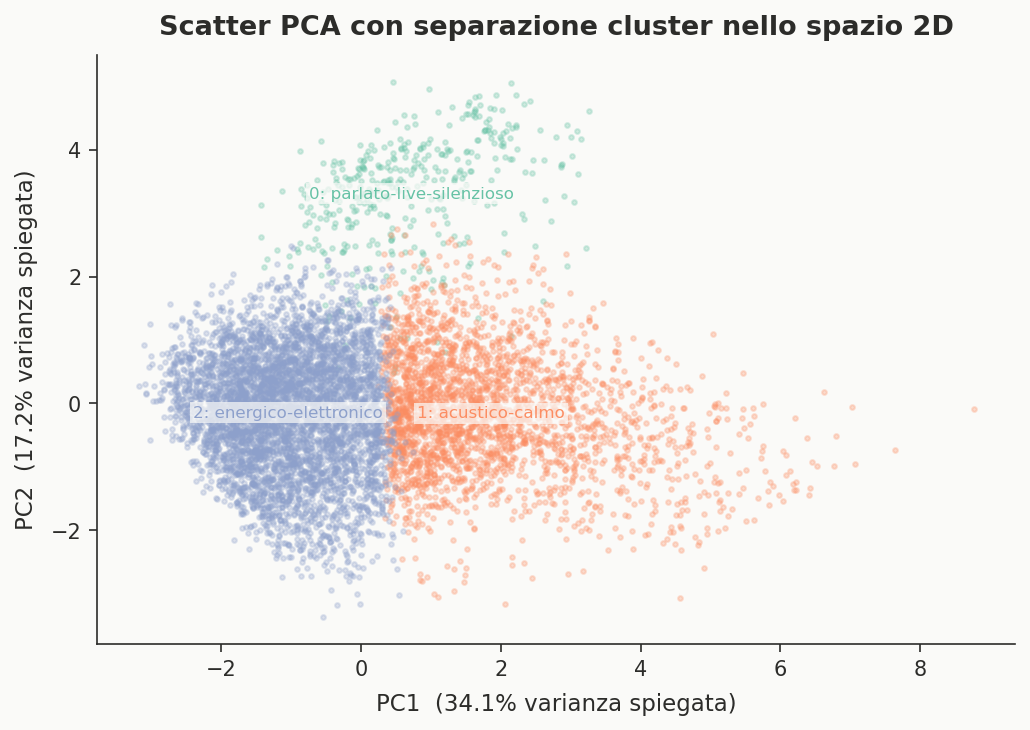

In [17]:
# Scatter PCA per verifica visiva della separazione dei cluster

pca_df["cluster"] = df_c["cluster"].values
pca_var = results["pca_explained"]

fig, ax = plt.subplots(figsize=(7, 5))
apply_style(ax)

sample_idx = np.random.default_rng(42).choice(len(pca_df), size=min(8000, len(pca_df)), replace=False)
sample_pca = pca_df.iloc[sample_idx]

for cluster_id in range(k):
    mask  = sample_pca["cluster"] == cluster_id
    color = CLUSTER_PALETTE[cluster_id % len(CLUSTER_PALETTE)]
    name  = cluster_names.get(int(cluster_id), f"C{cluster_id}")
    ax.scatter(sample_pca.loc[mask, "pc1"], sample_pca.loc[mask, "pc2"],
               color=color, alpha=0.28, s=5, zorder=2)

ax.set_xlabel(f"PC1  ({pca_var[0]*100:.1f}% varianza spiegata)")
ax.set_ylabel(f"PC2  ({pca_var[1]*100:.1f}% varianza spiegata)")
ax.set_title("Scatter PCA con separazione cluster nello spazio 2D", pad=10)
# Etichettatura diretta al centroide di ogni cluster (Tufte)
for _cid in range(k):
    _mask   = sample_pca["cluster"] == _cid
    _cx, _cy = sample_pca.loc[_mask, "pc1"].mean(), sample_pca.loc[_mask, "pc2"].mean()
    _name   = cluster_names.get(int(_cid), f"C{_cid}")
    _color  = CLUSTER_PALETTE[_cid % len(CLUSTER_PALETTE)]
    ax.text(_cx, _cy, f"{_cid}: {_name}", fontsize=8,
            ha="center", va="center", color=_color, fontweight="500",
            bbox=dict(facecolor="#FAFAF8", edgecolor="none", alpha=0.7, pad=1.5))

plt.tight_layout()
save_fig(fig, "m4_pca_scatter")
plt.show()


### Post-hoc Tests · Validazione Statistica dei Cluster

I cluster visibili nel Parallel Coordinates sono statisticamente distinti?
Kruskal-Wallis (globale per feature) + Mann-Whitney U (pairwise) + correzione FDR (Benjamini-Hochberg).

In [18]:
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests
from itertools import combinations

POSTHOC_FEATURES = [f for f in feature_names if f in df_c.columns]
cluster_ids = sorted(df_c["cluster"].unique())

# Kruskal-Wallis globale per feature
global_results = []
for feat in POSTHOC_FEATURES:
    groups = [df_c[df_c["cluster"] == c][feat].dropna().values for c in cluster_ids]
    stat, p = kruskal(*groups)
    global_results.append({"feature": feat, "H_stat": round(stat, 2), "p_global": p})

global_df = pd.DataFrame(global_results).sort_values("p_global")

display(
    global_df.style
    .format({"p_global": "{:.2e}", "H_stat": "{:.2f}"})
    .highlight_between(subset=["p_global"], left=0, right=0.05,
                       props="background-color: #E1F5EE; color: #085041")
    .hide(axis="index")
    .set_caption("Tab. 3 — Kruskal-Wallis: le feature differiscono tra cluster?")
)

# Mann-Whitney U pairwise (solo feature significative globalmente)
sig_features = global_df[global_df["p_global"] < 0.05]["feature"].tolist()
print(f"\nFeature con differenze globali (p < 0.05): {sig_features}")

pairwise_results = []
for feat in sig_features:
    for c1, c2 in combinations(cluster_ids, 2):
        x = df_c[df_c["cluster"] == c1][feat].dropna().values
        y = df_c[df_c["cluster"] == c2][feat].dropna().values
        stat, p = mannwhitneyu(x, y, alternative="two-sided")
        pairwise_results.append({
            "feature": feat,
            "cluster1": c1, "cluster2": c2,
            "pair": f"{c1} vs {c2}",
            "p_raw": p,
        })

pairwise_df = pd.DataFrame(pairwise_results)

# Correzione FDR Benjamini-Hochberg
pairwise_df["p_adj"] = multipletests(pairwise_df["p_raw"], method="fdr_bh")[1]

print(f"Confronti significativi dopo FDR: "
      f"{(pairwise_df['p_adj'] < 0.05).sum()} / {len(pairwise_df)}")

feature,H_stat,p_global
danceability,73004.09,0.00e+00
energy,230756.10,0.00e+00
valence,67892.09,0.00e+00
acousticness,189962.55,0.00e+00
instrumentalness,34016.05,0.00e+00
liveness,15851.95,0.00e+00
speechiness,66567.20,0.00e+00
loudness_norm,167603.29,0.00e+00



Feature con differenze globali (p < 0.05): ['danceability', 'energy', 'valence', 'acousticness', 'instrumentalness', 'liveness', 'speechiness', 'loudness_norm']
Confronti significativi dopo FDR: 24 / 24


  Salvataggio → figures/m4_posthoc_heatmap.png


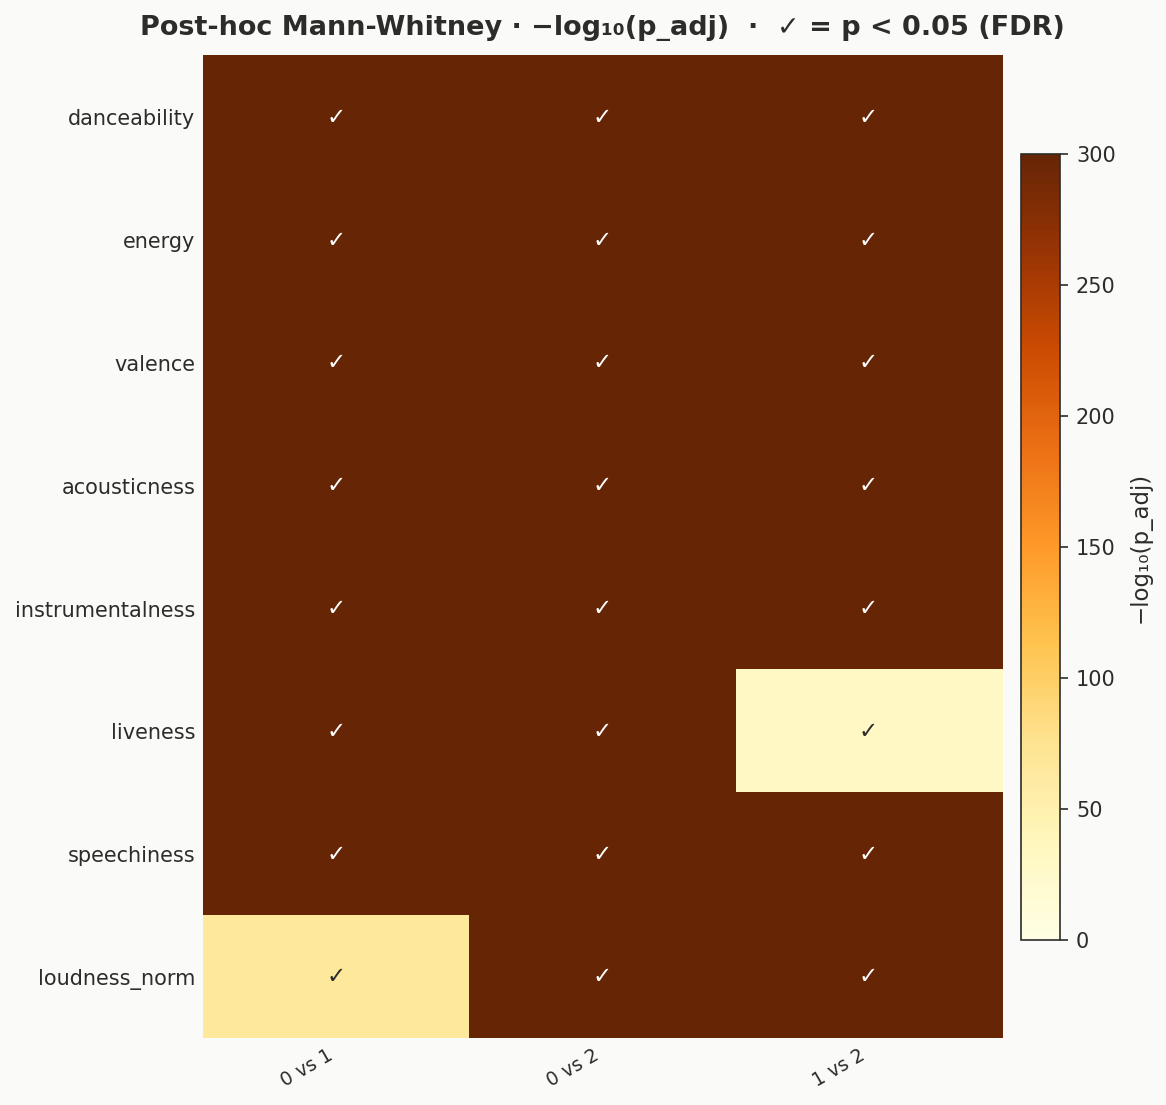


Feature caratterizzanti per cluster (tutti i confronti p < 0.05):
  Cluster 0 · parlato-live-silenzioso → ['danceability', 'energy', 'valence', 'acousticness', 'instrumentalness', 'liveness', 'speechiness', 'loudness_norm']
  Cluster 1 · acustico-calmo       → ['danceability', 'energy', 'valence', 'acousticness', 'instrumentalness', 'liveness', 'speechiness', 'loudness_norm']
  Cluster 2 · energico-elettronico → ['danceability', 'energy', 'valence', 'acousticness', 'instrumentalness', 'liveness', 'speechiness', 'loudness_norm']


In [19]:
# Heatmap −log10(p_adj): feature × coppia cluster

pairs = [f"{c1} vs {c2}" for c1, c2 in combinations(cluster_ids, 2)]
heatmap_data = pd.DataFrame(index=sig_features, columns=pairs, dtype=float)

for _, row in pairwise_df.iterrows():
    heatmap_data.loc[row["feature"], row["pair"]] = -np.log10(row["p_adj"] + 1e-300)

fig, ax = plt.subplots(
    figsize=(max(len(pairs) * 1.0 + 1.5, 8), len(sig_features) * 0.75 + 1.5)
)
apply_style(ax)

vmax = max(5.0, float(heatmap_data.values.astype(float).max()))
im = ax.imshow(
    heatmap_data.values.astype(float),
    cmap="YlOrBr", aspect="auto", vmin=0, vmax=vmax
)

thresh = -np.log10(0.05)   # ≈ 1.3
for i, feat in enumerate(sig_features):
    for j, pair in enumerate(pairs):
        val = float(heatmap_data.loc[feat, pair])
        txt = "✓" if val > thresh else "·"
        txt_color = "white" if val > vmax * 0.65 else "#2C2C2A"
        ax.text(j, i, txt, ha="center", va="center",
                fontsize=11, color=txt_color, fontweight="bold")

ax.set_xticks(range(len(pairs)))
ax.set_xticklabels(pairs, rotation=30, ha="right", fontsize=9)
ax.set_yticks(range(len(sig_features)))
ax.set_yticklabels(sig_features, fontsize=10)
ax.set_title("Post-hoc Mann-Whitney · −log₁₀(p_adj)  ·  ✓ = p < 0.05 (FDR)", pad=10)
fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02, label="−log₁₀(p_adj)")
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0)

plt.tight_layout()
save_fig(fig, "m4_posthoc_heatmap")
plt.show()

# Feature caratterizzanti per cluster
cluster_features = {}
for feat in sig_features:
    for c in cluster_ids:
        related = pairwise_df[
            ((pairwise_df["cluster1"] == c) | (pairwise_df["cluster2"] == c))
            & (pairwise_df["feature"] == feat)
        ]
        if all(related["p_adj"] < 0.05):
            cluster_features.setdefault(int(c), []).append(feat)

print("\nFeature caratterizzanti per cluster (tutti i confronti p < 0.05):")
for c, feats in sorted(cluster_features.items()):
    name = cluster_names.get(c, f"cluster {c}")
    print(f"  Cluster {c} · {name:<20} → {feats}")

**Osservazioni**

- **Elbow + Silhouette:** il k ottimale viene determinato automaticamente; se i due metodi
  suggeriscono k diversi, annotare qui la scelta e la motivazione.
- **Parallel Coordinates:** ogni cluster mostra un "profilo sonoro" distinto.
  I cluster con alta `acousticness` e bassa `energy` corrispondono tipicamente
  a musica classica o folk; quelli con alta `energy` e `danceability` a elettronica e pop.
- I nomi automatici (`name_clusters`) sono descrittivi — modificarli a mano se il
  profilo reale suggerisce un'etichetta più precisa.
- **Scatter PCA:** la sovrapposizione parziale in 2D è normale (8 feature ridotte a 2).
  La separazione è verificata dal Silhouette Score, non dalla proiezione 2D.


---
## Modulo 5: Decision Tree per la formula del successo

**Teoria applicata:**
- **Soto** — visualizzazione di alberi gerarchici:
  nodi colorati per classe, proporzione sample visibile, no ombreggiature
- **max_depth = 4** → albero leggibile in slide (max 16 foglie);
  la complessità è sacrificata in favore della leggibilità visiva del modello
- **class_weight = "balanced"** → compensazione dello sbilanciamento
  hit / non-hit senza ricorrere a SMOTE (più semplice, sufficientemente robusto)

**Domanda:** Quali feature audio rendono un brano una hit?  
**Target:** `is_hit = 1` se `popularity ≥ 60`  (~35% dei brani nel dataset pulito)

**Nota metodologica:** Random Forest sarebbe più accurato, ma un Decision Tree
singolo è l'unico modello che si può *visualizzare* — requisito esplicito del modulo
(Soto: visualizzazione alberi gerarchici). L'accuracy del RF viene comunque riportata
nella tabella comparativa come riferimento.


In [20]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)
from sklearn.dummy import DummyClassifier

# Carica df_c da CSV se M4 non è stato eseguito
try:
    df_c
except NameError:
    df_c = pd.read_csv("data/spotify_clustered.csv")
    feature_names = [f for f in CLUSTER_FEATURES if f in df_c.columns]
    k = int(df_c["cluster"].nunique())
    print(f"df_c caricato da CSV  ({len(df_c):,} brani, k={k})")

# Includiamo la colonna 'cluster' di M4 come feature aggiuntiva
MODEL_FEATURES = [f for f in feature_names if f in df_c.columns] + ["cluster"]

X = df_c[MODEL_FEATURES].dropna()
y = df_c.loc[X.index, "is_hit"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train):>7,} brani  ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test set    : {len(X_test):>7,} brani  ({len(X_test)/len(X)*100:.0f}%)")
print(f"Prevalenza hit (train): {y_train.mean()*100:.1f}%")


Training set: 318,680 brani  (80%)
Test set    :  79,670 brani  (20%)
Prevalenza hit (train): 5.6%


In [21]:
# Addestramento e confronto modelli
DT_DEPTH = 3

models = {
    "Baseline (majority)": DummyClassifier(strategy="most_frequent", random_state=42),
    "Decision Tree":        DecisionTreeClassifier(
                                max_depth=DT_DEPTH,
                                class_weight="balanced",
                                random_state=42
                            ),
    "Random Forest":        RandomForestClassifier(
                                n_estimators=100,
                                class_weight="balanced",
                                random_state=42,
                                n_jobs=-1
                            ),
}

results_m5 = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results_m5[name] = {
        "accuracy": round(accuracy_score(y_test, y_pred), 3),
        "f1_macro": round(f1_score(y_test, y_pred, average="macro"), 3),
    }

# Tabella comparativa (Stephen Few: solo le misure necessarie)
comp_df = pd.DataFrame(results_m5).T
print("\nConfronto modelli (test set):")
display(
    comp_df.style
    .format("{:.3f}")
    .highlight_max(axis=0, props="font-weight: 500; color: #0F6E56")
    .set_properties(**{"text-align": "right"})
    .set_caption("Tab. 2 — Accuracy e F1-macro sul test set (20%)")
)

dt = models["Decision Tree"]
print(f"\nDecision Tree: depth={dt.get_depth()}, foglie={dt.get_n_leaves()}")



Confronto modelli (test set):


,accuracy,f1_macro
Baseline (majority),0.944,0.486
Decision Tree,0.606,0.455
Random Forest,0.944,0.494



Decision Tree: depth=3, foglie=8


  Salvataggio → figures/m5_decision_tree.png


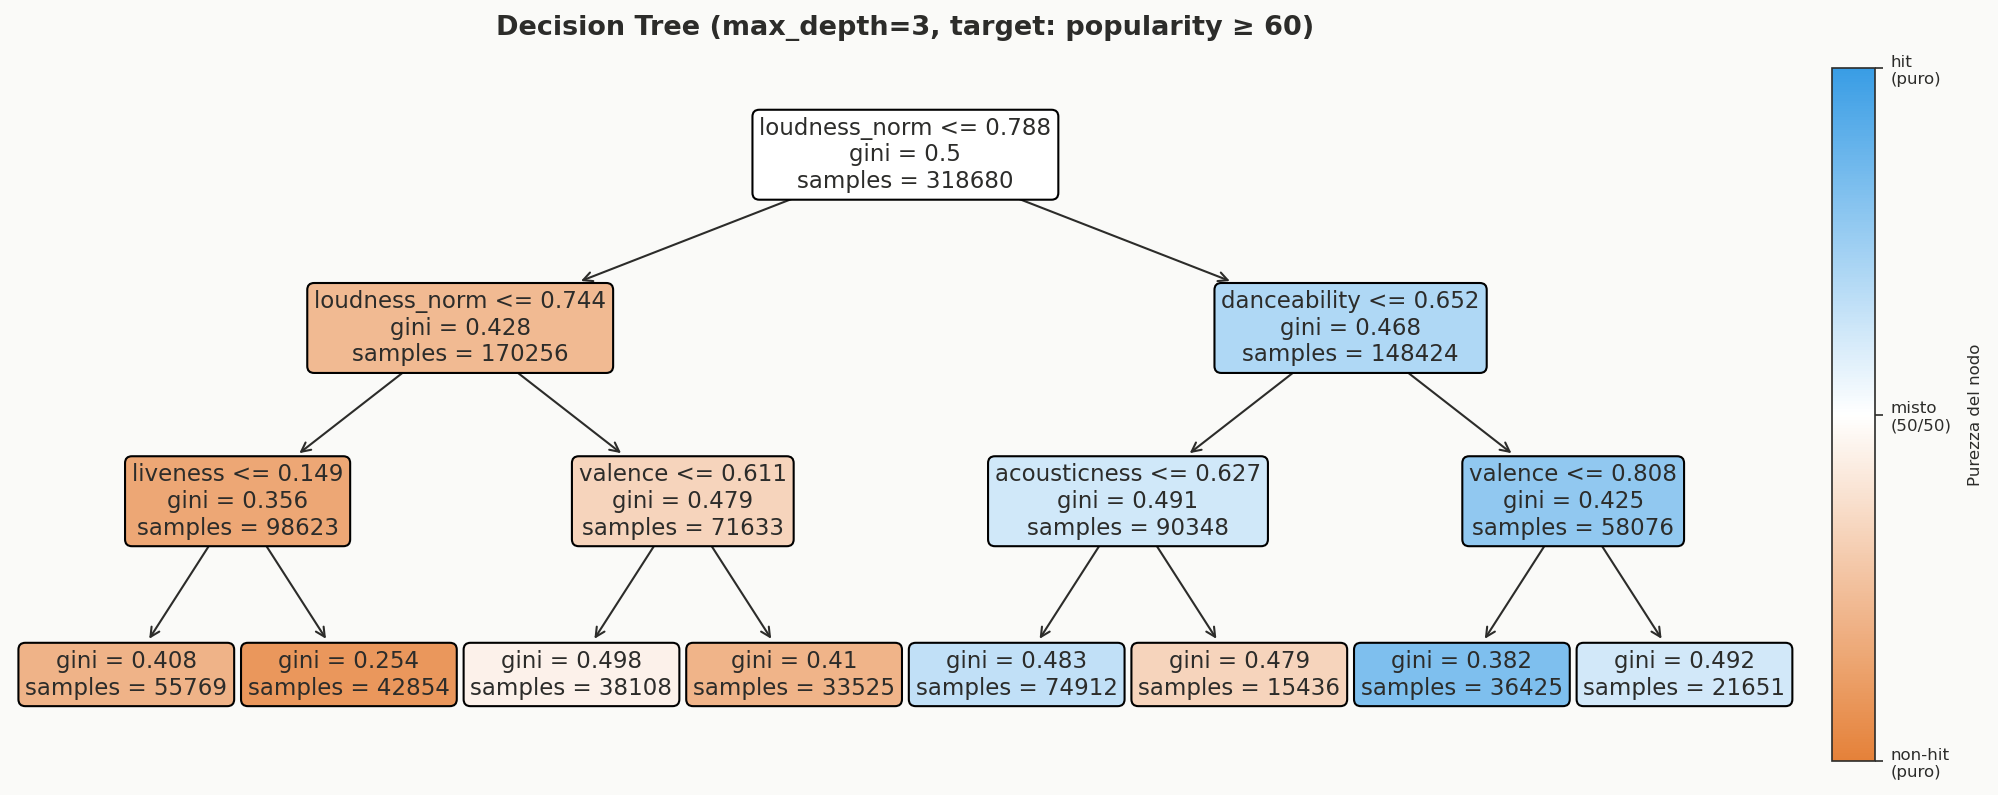

In [22]:
# Visualizzazione Decision Tree — stile Soto
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable

fig = plt.figure(figsize=(16, 6))
fig.patch.set_facecolor("#FAFAF8")

# Layout: albero (ampio) | legenda (stretta)
gs = gridspec.GridSpec(1, 2, width_ratios=[50, 1.2], figure=fig, wspace=0.04)
ax     = fig.add_subplot(gs[0])
ax_leg = fig.add_subplot(gs[1])
ax.set_facecolor("#FAFAF8")

plot_tree(
    dt,
    feature_names=MODEL_FEATURES,
    class_names=["non-hit", "hit"],
    filled=True,
    rounded=True,
    impurity=True,
    proportion=False,
    fontsize=11,
    ax=ax,
    precision=3,
)

for ann in ax.texts:
    lines = ann.get_text().split("\n")
    lines = [l for l in lines if not l.strip().startswith(("value =", "class ="))]
    ann.set_text("\n".join(lines))

ax.set_title(
    f"Decision Tree (max_depth={DT_DEPTH}, target: popularity ≥ 60)",
    fontsize=13, fontweight="bold", pad=16
)
for spine in ax.spines.values():
    spine.set_visible(False)

# ── Legenda colori ────────────────────────────────────────────────────────
# sklearn usa internamente due colori fissi per filled=True:
#   class 0 (non-hit) → #e58139  (arancione)
#   class 1 (hit)     → #399de5  (blu)
# I nodi con distribuzione 50/50 tendono al bianco (Gini ≈ 0.5).
# La legenda esplicita questa scala così da non costringere la commissione
# a leggere i valori numerici in ogni nodo per capire il colore.
cmap_leg = mcolors.LinearSegmentedColormap.from_list(
    "dt_classes",
    ["#e58139", "#ffffff", "#399de5"],
    N=256,
)

norm_leg = mcolors.Normalize(vmin=0, vmax=1)

sm = ScalarMappable(cmap=cmap_leg, norm=norm_leg)
sm.set_array([])
cb = fig.colorbar(sm, cax=ax_leg, orientation="vertical")

cb.set_ticks([0.0, 0.5, 1.0])
cb.set_ticklabels(["non-hit\n(puro)", "misto\n(50/50)", "hit\n(puro)"])
cb.ax.tick_params(labelsize=8)
cb.set_label("Purezza del nodo", fontsize=8, labelpad=8)

plt.tight_layout()
save_fig(fig, "m5_decision_tree")
plt.show()

  Salvataggio → figures/m5_dt_diagnostics.png


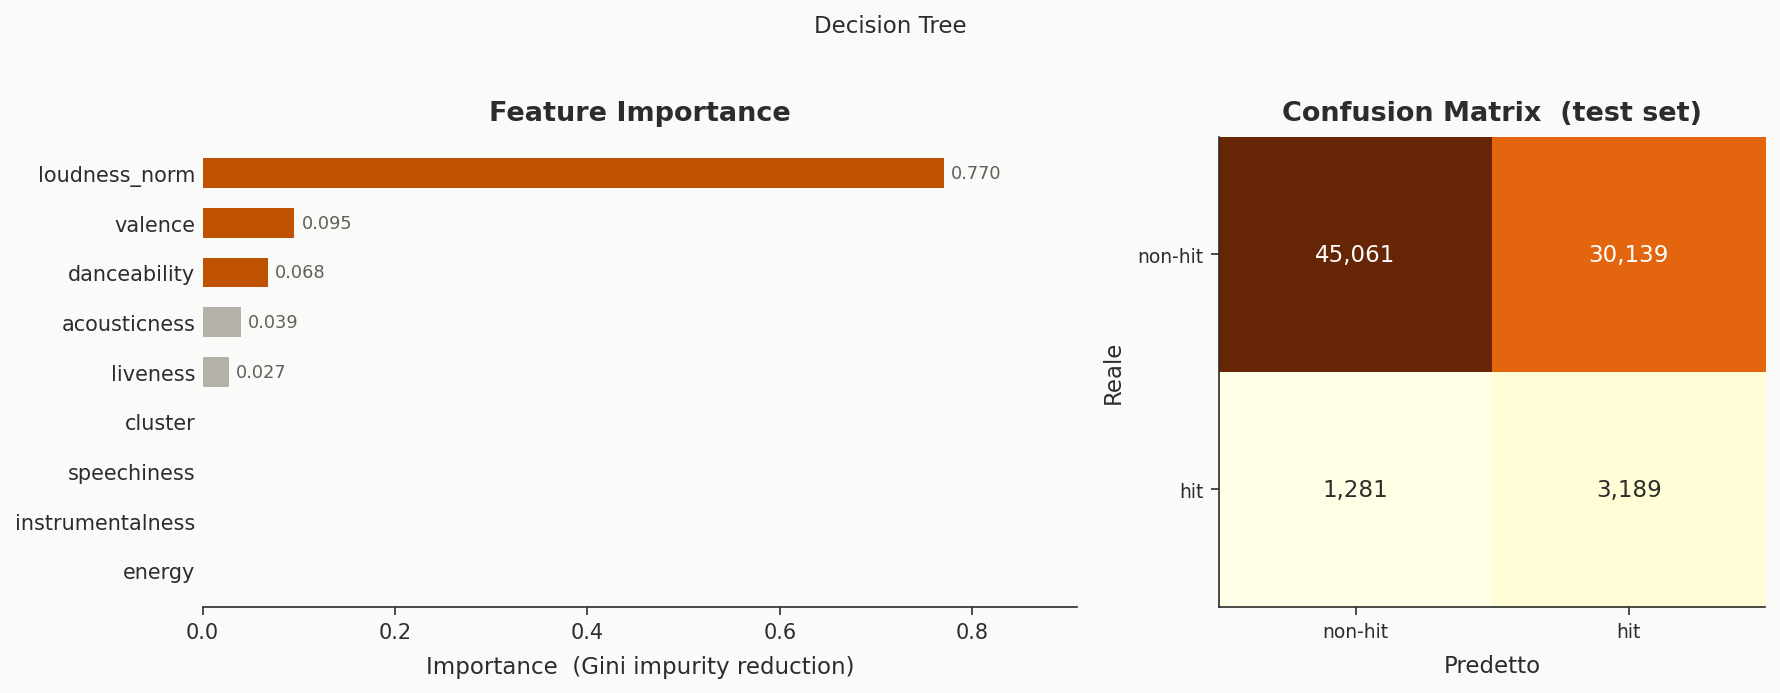

              precision    recall  f1-score   support

     non-hit       0.97      0.60      0.74     75200
         hit       0.10      0.71      0.17      4470

    accuracy                           0.61     79670
   macro avg       0.53      0.66      0.46     79670
weighted avg       0.92      0.61      0.71     79670



In [23]:
# Decision Tree: Feature Importance + Confusion Matrix

importances = pd.Series(dt.feature_importances_, index=MODEL_FEATURES)
importances = importances.sort_values(ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5),
                                gridspec_kw={"width_ratios": [1.6, 1]})
apply_style(ax1)
apply_style(ax2)

# Feature Importance (quali feature contano di più)
bar_colors = [HIGHLIGHT if v > importances.quantile(0.65) else MUTED
              for v in importances.values]
bars = ax1.barh(importances.index, importances.values,
                color=bar_colors, height=0.6)
for bar, val in zip(bars, importances.values):
    if val > 0.005:
        ax1.text(val + importances.max() * 0.01,
                 bar.get_y() + bar.get_height() / 2,
                 f"{val:.3f}", va="center", fontsize=8.5, color="#5F5E5A")

ax1.set_xlabel("Importance  (Gini impurity reduction)")
ax1.set_title("Feature Importance", pad=8)
ax1.spines["left"].set_visible(False)
ax1.tick_params(axis="y", length=0)
ax1.set_xlim(0, importances.max() * 1.18)

# Confusion Matrix (quanto bene funziona il modello)
y_pred_dt = dt.predict(X_test)
cm = confusion_matrix(y_test, y_pred_dt)
labels = ["non-hit", "hit"]

im = ax2.imshow(cm, interpolation="nearest", cmap="YlOrBr", aspect="auto")
ax2.set_xticks([0, 1])
ax2.set_xticklabels(labels, fontsize=9)
ax2.set_yticks([0, 1])
ax2.set_yticklabels(labels, fontsize=9)
ax2.set_xlabel("Predetto")
ax2.set_ylabel("Reale")
ax2.set_title("Confusion Matrix  (test set)", pad=8)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

thresh = cm.max() / 2
for i in range(2):
    for j in range(2):
        ax2.text(j, i, f"{cm[i, j]:,}",
                 ha="center", va="center", fontsize=11,
                 color="white" if cm[i, j] > thresh else "#2C2C2A",
                 fontweight="500")

fig.suptitle("Decision Tree", fontsize=11, y=1.02)
plt.tight_layout()
save_fig(fig, "m5_dt_diagnostics")
plt.show()

# Report testuale
print(classification_report(y_test, y_pred_dt, target_names=["non-hit", "hit"]))


**Osservazioni**

- **Feature più importante:** Le feature `loudness_norm`, `valence` e `danceability`  compaiono ai primi livelli dell'albero.
- **Confusion Matrix:** il modello tende a classificare meglio i non-hit (classe
  maggioritaria) — `class_weight="balanced"` attenua ma non elimina lo sbilanciamento.